In [12]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

# Define symbolic variables
a11, a12, a21, a22 = sp.symbols('a11 a12 a21 a22')
b1, b2 = sp.symbols('b1 b2')
c1, c2 = sp.symbols('c1 c2')
d = sp.symbols('d')

# Define symbolic matrices
A = sp.Matrix([[a11, a12], 
                [a21, a22]])
B = sp.Matrix([[b1], 
                [b2]])
C = sp.Matrix([[c1, c2]])
D = sp.Matrix([[d]])

# Create the graph
G = nx.DiGraph()

num_states = A.shape[0]
num_inputs = B.shape[1]
num_outputs = C.shape[0]

# Add input node
G.add_node('u', label='u (Input)')

# Add state nodes
for i in range(num_states):
    G.add_node(f'x{i+1}', label=f'x{i+1} (State {i+1})')

# Add output node
G.add_node('y', label='y (Output)')

# Add edges based on B (input to states)
for i in range(num_states):
    for j in range(num_inputs):
        if B[i, j] != 0:
            G.add_edge('u', f'x{i+1}', weight=1.0, label=f'B[{i+1}][{j+1}]={B[i, j]}')  # Numeric weight

# Add edges based on A (state to state)
for i in range(num_states):
    for j in range(num_states):
        if A[i, j] != 0:
            G.add_edge(f'x{j+1}', f'x{i+1}', weight=1.0, label=f'A[{i+1}][{j+1}]={A[i, j]}')  # Numeric weight

# Add edges based on C (states to output)
for i in range(num_states):
    for j in range(num_outputs):
        if C[j, i] != 0:
            G.add_edge(f'x{i+1}', 'y', weight=1.0, label=f'C[{j+1}][{i+1}]={C[j, i]}')  # Numeric weight

# Add edges based on D (input to output)
for i in range(num_outputs):
    for j in range(num_inputs):
        if D[i, j] != 0:
            G.add_edge('u', 'y', weight=1.0, label=f'D[{i+1}][{j+1}]={D[i, j]}')  # Numeric weight

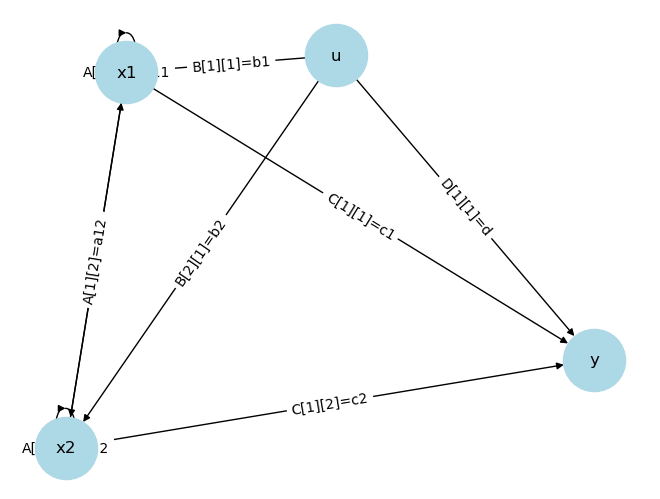

In [13]:
# Automatically create a layout
pos = nx.spring_layout(G)  # Change to other layouts like nx.circular_layout(G) if desired

# Draw the nodes in the normal layout
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue')

# Draw the edges with symbolic labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Show the plot
plt.show()

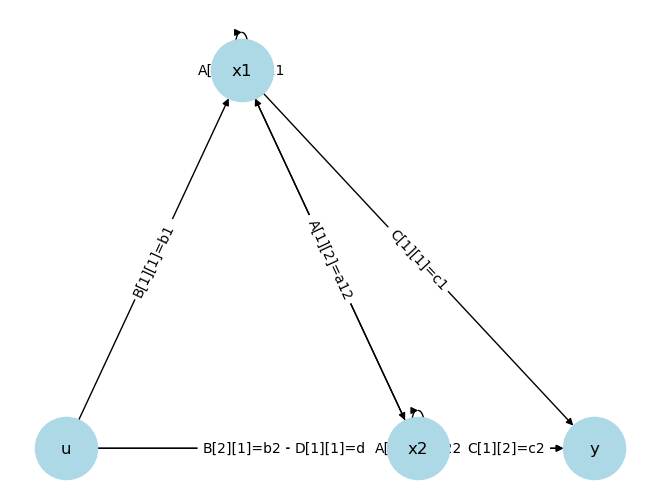

In [14]:
# Manually create a cascade layout: input -> states -> output
pos = {
    'u': (0, 0),     # Input on the left
    'x1': (1, 1),    # State 1 in the middle layer
    'x2': (2, 0),    # State 2 in the middle layer
    'y': (3, 0)      # Output on the right
}

# Draw the nodes in the custom cascade layout
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue')

# Draw the edges with symbolic labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Show the plot
plt.show()

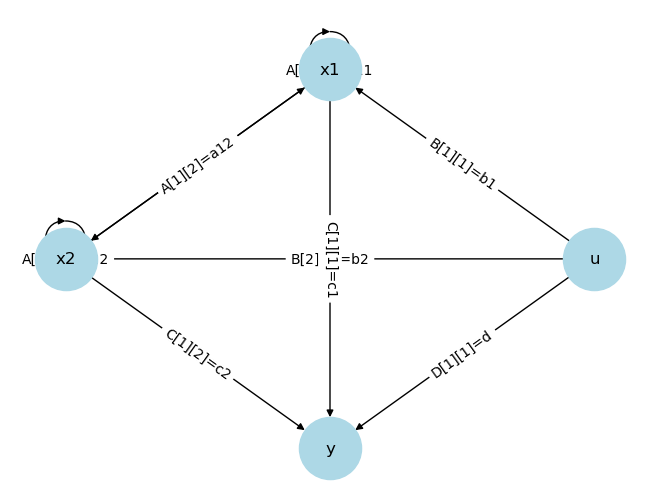

In [15]:
# Automatically create a circular layout
pos = nx.circular_layout(G)  # Change to circular layout

# Draw the nodes in the circular layout
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue')

# Draw the edges with symbolic labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Show the plot
plt.show()